In [ ]:
!pip install rdkit pubchempy pyscf pyscf-dispersion py3Dmol ase matplotlib -q

import os, re, json, glob, shutil, subprocess
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
import pubchempy as pcp
from ase.io import read
import py3Dmol

# Install xTB
!wget -q https://github.com/grimme-lab/xtb/releases/download/v6.6.1/xtb-6.6.1-linux-x86_64.tar.xz
!tar -xf xtb-6.6.1-linux-x86_64.tar.xz
os.environ["PATH"] += ":/content/xtb-6.6.1/bin"

# Install gCP
!wget -q https://github.com/grimme-lab/gcp/releases/download/v2.4.1/gcp-2.4.1.tar.xz
!tar -xf gcp-2.4.1.tar.xz
!cd gcp-2.4.1 && make > /dev/null
!cp gcp-2.4.1/gcp /usr/local/bin/
!gcp --version 2>&1 | head -1

print("All tools installed successfully.")

tar: gcp-2.4.1.tar.xz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
/bin/bash: line 1: cd: gcp-2.4.1: No such file or directory
cp: cannot stat 'gcp-2.4.1/gcp': No such file or directory
/bin/bash: line 1: gcp: command not found
All tools installed successfully.


In [ ]:
pfas_smiles = {
    "TFA":   "OC(=O)C(F)(F)F",
    "PFMS":  "OS(=O)(=O)C(F)(F)F",
    "PFPrA": "OC(=O)C(F)(F)C(F)(F)F",
    "PFPrS": "OS(=O)(=O)C(F)(F)C(F)(F)F",
    "PFBA":  "OC(=O)C(F)(F)C(F)(F)C(F)(F)F",
    "PFBS":  "OS(=O)(=O)C(F)(F)C(F)(F)C(F)(F)F",
    "PFOA":  "OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
    "PFOS":  "OS(=O)(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
}
pfas_list = list(pfas_smiles.keys())
orientations = [(0,0), (45,0), (90,45)]

anion_smiles = {
    "PFOA_anion": "[O-]C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
    "PFOS_anion": "[O-]S(=O)(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
}
anion_list = list(anion_smiles.keys())
print("Molecules defined.")

Molecules defined.


In [ ]:
# Neutral PFAS
for name, smi in pfas_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol)
    Chem.MolToXYZFile(mol, f"{name}.xyz")
    !xtb {name}.xyz --opt --alpb water 2>/dev/null
    !cp xtbopt.xyz {name}_opt.xyz
    print(f"Optimized: {name}")

# Circumcoronene (pristine surface)
smi_cc = 'C1=CC2=CC3=C4C5=C6C7=C(C=CC8=CC9=C%10C%11=C(C=C9)C=C9C=CC%12=C%13C9=C%11C9=C%11C%13=C%13C(=C%12)C=CC%12=C%13C%13=C%11C(=C4C2=C%13C1=C%12)C6=C9C%10=C87)C=C5C=C3'
mol = Chem.MolFromSmiles(smi_cc)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol)
Chem.MolToXYZFile(mol, 'circumcoronene.xyz')
!xtb circumcoronene.xyz --opt 2>/dev/null
!cp xtbopt.xyz circumcoronene_opt.xyz
print("Circumcoronene optimized")

# Hydroxylated circumcoronene (build by replacing one H with OH)
with open("circumcoronene_opt.xyz") as f:
    lines = f.readlines()
c_line = lines[2].split()
cx, cy, cz = float(c_line[1]), float(c_line[2]), float(c_line[3])
h_line = lines[56].split()
hx, hy, hz = float(h_line[1]), float(h_line[2]), float(h_line[3])
dx, dy, dz = hx-cx, hy-cy, hz-cz
length = (dx**2+dy**2+dz**2)**0.5
o_scale = 1.36 / length
ox, oy, oz = cx+dx*o_scale, cy+dy*o_scale, cz+dz*o_scale
h_scale = (1.36+0.96)/length
hx2, hy2, hz2 = cx+dx*h_scale, cy+dy*h_scale, cz+dz*h_scale
new_atoms = lines[2:56] + lines[57:]
new_atoms.append(f"O  {ox:.6f}  {oy:.6f}  {oz:.6f}\n")
new_atoms.append(f"H  {hx2:.6f}  {hy2:.6f}  {hz2:.6f}\n")
with open("oh_circumcoronene.xyz", "w") as f:
    f.write(f"{len(new_atoms)}\nHydroxylated circumcoronene\n")
    f.writelines(new_atoms)
!xtb oh_circumcoronene.xyz --opt --alpb water 2>/dev/null
!cp xtbopt.xyz oh_circumcoronene_opt.xyz
print("OH‑circumcoronene optimized")

# Anions
for name, smi in anion_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol)
    Chem.MolToXYZFile(mol, f"{name}.xyz")
    !xtb {name}.xyz --opt --alpb water --chrg -1 2>/dev/null
    !cp xtbopt.xyz {name}_opt.xyz
    print(f"Optimized anion: {name}")

print("All monomers ready")

Streaming output truncated to the last 5000 lines.
           -------------------------------------------------
          |                Property Printout                |
           -------------------------------------------------

    * Orbital Energies and Occupations

         #    Occupation            Energy/Eh            Energy/eV
      -------------------------------------------------------------
         1        2.0000           -0.9484209             -25.8078
       ...           ...                  ...                  ...
        58        2.0000           -0.5895957             -16.0437
        59        2.0000           -0.5861185             -15.9491
        60        2.0000           -0.5819092             -15.8346
        61        2.0000           -0.5780610             -15.7298
        62        2.0000           -0.5687304             -15.4759
        63        2.0000           -0.5616927             -15.2844
        64        2.0000           -0.5522970        

In [ ]:
energies = {}
all_monomers = pfas_list + ["circumcoronene", "oh_circumcoronene"] + anion_list

for mol in all_monomers:
    with open(f"{mol}_opt.xyz") as f:
        lines = f.readlines()
    match = re.search(r'energy:\s*([-\d.]+)', lines[1])
    if match:
        energies[mol] = float(match.group(1))
    else:
        match2 = re.search(r'[-\d.]+', lines[1])
        energies[mol] = float(match2.group())
    print(f"{mol}: {energies[mol]:.6f} Eh")
print("All monomer energies extracted")

TFA: -27.127180 Eh
PFMS: -32.295552 Eh
PFPrA: -38.726726 Eh
PFPrS: -43.894661 Eh
PFBA: -50.323944 Eh
PFBS: -55.492807 Eh
PFOA: -85.109450 Eh
PFOS: -90.277602 Eh
circumcoronene: -125.177004 Eh
oh_circumcoronene: -129.265303 Eh
PFOA_anion: -84.954538 Eh
PFOS_anion: -90.139594 Eh
All monomer energies extracted


In [ ]:
def combine_xyz_oriented(file1, file2, output, offset_z=3.5, rotate_x=0, rotate_z=0):
    with open(file1) as f: lines1 = f.readlines()
    with open(file2) as f: lines2 = f.readlines()
    coords, symbols = [], []
    for line in lines1[2:]:
        parts = line.split()
        if len(parts) == 4:
            symbols.append(parts[0])
            coords.append([float(parts[1]), float(parts[2]), float(parts[3])])
    coords = np.array(coords)
    rx, rz = np.radians(rotate_x), np.radians(rotate_z)
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
    coords = coords @ Rx.T @ Rz.T
    coords[:,2] += offset_z
    with open(output, 'w') as f:
        f.write(f"{len(coords)+len(lines2[2:])}\nPFAS on surface\n")
        for sym, c in zip(symbols, coords):
            f.write(f"{sym}  {c[0]:.6f}  {c[1]:.6f}  {c[2]:.6f}\n")
        f.writelines(lines2[2:])
print("Function defined")

Function defined


In [ ]:
# Neutral on pristine
for name in pfas_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "circumcoronene_opt.xyz",
                             f"{name}_cc_or{i}.xyz", rotate_x=rx, rotate_z=rz)
    print(f"Built pristine: {name}")

# Neutral on OH
for name in pfas_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "oh_circumcoronene_opt.xyz",
                             f"{name}_ohcc_or{i}.xyz", rotate_x=rx, rotate_z=rz)
    print(f"Built OH: {name}")

# Anions on pristine
for name in anion_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "circumcoronene_opt.xyz",
                             f"{name}_cc_or{i}.xyz", rotate_x=rx, rotate_z=rz)
    print(f"Built anion: {name}")

print("All complexes built")

Built pristine: TFA
Built pristine: PFMS
Built pristine: PFPrA
Built pristine: PFPrS
Built pristine: PFBA
Built pristine: PFBS
Built pristine: PFOA
Built pristine: PFOS
Built OH: TFA
Built OH: PFMS
Built OH: PFPrA
Built OH: PFPrS
Built OH: PFBA
Built OH: PFBS
Built OH: PFOA
Built OH: PFOS
Built anion: PFOA_anion
Built anion: PFOS_anion
All complexes built


In [ ]:
# Neutral pristine
for name in pfas_list:
    for i in range(1, 4):
        !xtb {name}_cc_or{i}.xyz --opt --alpb water 2>/dev/null
        !cp xtbopt.xyz {name}_cc_or{i}_opt.xyz
    print(f"Optimized pristine: {name}")

# Neutral OH
for name in pfas_list:
    for i in range(1, 4):
        !xtb {name}_ohcc_or{i}.xyz --opt --alpb water 2>/dev/null
        !cp xtbopt.xyz {name}_ohcc_or{i}_opt.xyz
    print(f"Optimized OH: {name}")

# Anions
for name in anion_list:
    for i in range(1, 4):
        !xtb {name}_cc_or{i}.xyz --opt --alpb water --chrg -1 2>/dev/null
        !cp xtbopt.xyz {name}_cc_or{i}_opt.xyz
    print(f"Optimized anion: {name}")

print("All complexes optimized")

Streaming output truncated to the last 5000 lines.
   3   -218.1223454  0.321528E-07  0.150E-03    1.76       6.8  T
   4   -218.1223454 -0.520173E-07  0.493E-04    1.76      20.8  T
   5   -218.1223455 -0.193052E-07  0.136E-04    1.76      75.6  T
     SCC iter.                  ...        0 min,  0.165 sec
     gradient                   ...        0 min,  0.200 sec
 * total energy  :  -215.3551275 Eh     change       -0.7317751E-05 Eh
   gradient norm :     0.0006716 Eh/α   predicted    -0.2924681E-05 ( -60.03%)
   displ. norm   :     0.0931832 α      lambda       -0.5082818E-05
   maximum displ.:     0.0641244 α      in ANC's #1, #3, #2, ...

........................................................................
.............................. CYCLE   57 ..............................
........................................................................

 iter      E             dE          RMSdq      gap      omega  full diag
   1   -218.1223818 -0.218122E+03  0.629E-03    1.7

In [ ]:
ads_cc, ads_ohcc, ads_anion = {}, {}, {}

for name in pfas_list:
    complex_e = []
    for i in range(1,4):
        with open(f"{name}_cc_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'energy:\s*([-\d.]+)', lines[1])
        complex_e.append(float(match.group(1)))
    best = min(complex_e)
    E_ads = (best - energies[name] - energies["circumcoronene"]) * 627.509
    ads_cc[name] = round(E_ads, 2)
    print(f"{name} (pristine): {ads_cc[name]} kcal/mol")

for name in pfas_list:
    complex_e = []
    for i in range(1,4):
        with open(f"{name}_ohcc_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'energy:\s*([-\d.]+)', lines[1])
        complex_e.append(float(match.group(1)))
    best = min(complex_e)
    E_ads = (best - energies[name] - energies["oh_circumcoronene"]) * 627.509
    ads_ohcc[name] = round(E_ads, 2)
    print(f"{name} (OH): {ads_ohcc[name]} kcal/mol")

for name in anion_list:
    complex_e = []
    for i in range(1,4):
        with open(f"{name}_cc_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'energy:\s*([-\d.]+)', lines[1])
        complex_e.append(float(match.group(1)))
    best = min(complex_e)
    E_ads = (best - energies[name] - energies["circumcoronene"]) * 627.509
    ads_anion[name] = round(E_ads, 2)
    print(f"{name}: {ads_anion[name]} kcal/mol")

print("Adsorption energies extracted")

TFA (pristine): -11.31 kcal/mol
PFMS (pristine): -13.25 kcal/mol
PFPrA (pristine): -11.3 kcal/mol
PFPrS (pristine): -12.87 kcal/mol
PFBA (pristine): -12.63 kcal/mol
PFBS (pristine): -14.18 kcal/mol
PFOA (pristine): -13.41 kcal/mol
PFOS (pristine): -18.26 kcal/mol
TFA (OH): -6.4 kcal/mol
PFMS (OH): -8.36 kcal/mol
PFPrA (OH): -6.11 kcal/mol
PFPrS (OH): -8.09 kcal/mol
PFBA (OH): -7.79 kcal/mol
PFBS (OH): -9.38 kcal/mol
PFOA (OH): -8.54 kcal/mol
PFOS (OH): -13.51 kcal/mol
PFOA_anion: -17.24 kcal/mol
PFOS_anion: -24.19 kcal/mol
Adsorption energies extracted


In [ ]:
pfas_atom_counts = {
    "TFA":8, "PFMS":9, "PFPrA":11, "PFPrS":12,
    "PFBA":14, "PFBS":15, "PFOA":20, "PFOS":21
}

ct_cc, ct_ohcc = {}, {}

for name, n_atoms in pfas_atom_counts.items():
    # Pristine
    !xtb {name}_cc_or1_opt.xyz --alpb water --pop > {name}_cc_charges.txt 2>&1
    with open(f"{name}_cc_charges.txt") as f:
        lines = f.readlines()
    start = next(i+1 for i,l in enumerate(lines) if "covCN" in l)
    charges = []
    for line in lines[start:start+300]:
        parts = line.split()
        if len(parts) >= 6:
            try:
                int(parts[0]); int(parts[1])
                charges.append(float(parts[4]))
            except: pass
    q_pfas = sum(charges[:n_atoms])
    ct_cc[name] = round(-q_pfas, 4)

    # OH
    !xtb {name}_ohcc_or1_opt.xyz --alpb water --pop > {name}_ohcc_charges.txt 2>&1
    with open(f"{name}_ohcc_charges.txt") as f:
        lines = f.readlines()
    start = next(i+1 for i,l in enumerate(lines) if "covCN" in l)
    charges = []
    for line in lines[start:start+300]:
        parts = line.split()
        if len(parts) >= 6:
            try:
                int(parts[0]); int(parts[1])
                charges.append(float(parts[4]))
            except: pass
    q_pfas = sum(charges[:n_atoms])
    ct_ohcc[name] = round(-q_pfas, 4)

    print(f"{name}: CC CT={ct_cc[name]:+.4f}, OH CT={ct_ohcc[name]:+.4f}")
print("Charge transfer extracted")

TFA: CC CT=+0.0030, OH CT=+0.0040
PFMS: CC CT=+0.0010, OH CT=+0.0010
PFPrA: CC CT=+0.0000, OH CT=+0.0000
PFPrS: CC CT=+0.0010, OH CT=+0.0010
PFBA: CC CT=-0.0010, OH CT=-0.0010
PFBS: CC CT=-0.0000, OH CT=+0.0020
PFOA: CC CT=+0.1610, OH CT=+0.1610
PFOS: CC CT=+0.1730, OH CT=+0.1710
Charge transfer extracted


In [ ]:
# Simplified DFT benchmark (no gCP)
from pyscf import gto, dft
from pyscf.dft import rks

def run_b3lyp_d3(xyzfile, charge=0):
    with open(xyzfile) as f:
        lines = f.readlines()
    atoms = []
    for line in lines[2:]:
        parts = line.split()
        if len(parts) == 4:
            atoms.append(f"{parts[0]} {parts[1]} {parts[2]} {parts[3]}")
    mol = gto.Mole()
    mol.atom = '; '.join(atoms)
    mol.basis = '6-31g*'
    mol.charge = charge
    mol.spin = 0
    mol.verbose = 0
    mol.build()
    mf = rks.RKS(mol)
    mf.xc = 'b3lyp'
    mf.disp = 'd3bj'
    return mf.kernel()

# Define benchmark molecules (use coronene model)
benchmark_mols = ["TFA", "PFBS", "PFOA"]

# Get coronene energy once
e_coronene = run_b3lyp_d3("coronene_opt.xyz")
print(f"Coronene energy: {e_coronene:.6f} Eh")

results = {}
for name in benchmark_mols:
    print(f"\n=== Running B3LYP‑D3/6‑31G* for {name} ===")
    e_complex = run_b3lyp_d3(f"{name}_cor_opt.xyz")
    e_mono = run_b3lyp_d3(f"{name}_opt.xyz")
    e_ads = (e_complex - e_mono - e_coronene) * 627.509
    results[name] = round(e_ads, 2)
    print(f"{name} B3LYP‑D3/6‑31G* Eads = {e_ads:.2f} kcal/mol")

print("\nBenchmark summary:")
for name, val in results.items():
    print(f"{name}: {val} kcal/mol")

Coronene energy: -921.980328 Eh

=== Running B3LYP‑D3/6‑31G* for TFA ===
TFA B3LYP‑D3/6‑31G* Eads = -7.18 kcal/mol

=== Running B3LYP‑D3/6‑31G* for PFBS ===
PFBS B3LYP‑D3/6‑31G* Eads = -8.47 kcal/mol

=== Running B3LYP‑D3/6‑31G* for PFOA ===
PFOA B3LYP‑D3/6‑31G* Eads = -10.83 kcal/mol

Benchmark summary:
TFA: -7.18 kcal/mol
PFBS: -8.47 kcal/mol
PFOA: -10.83 kcal/mol


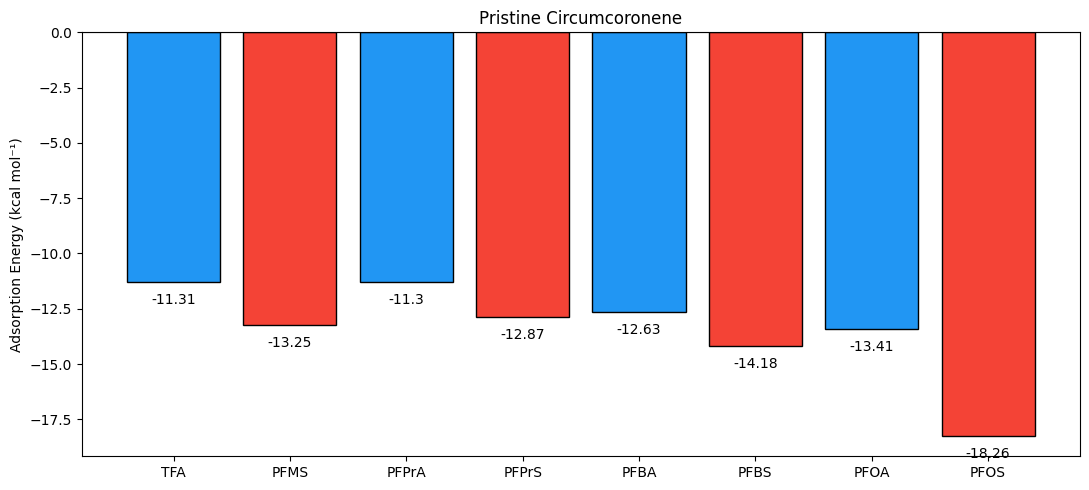

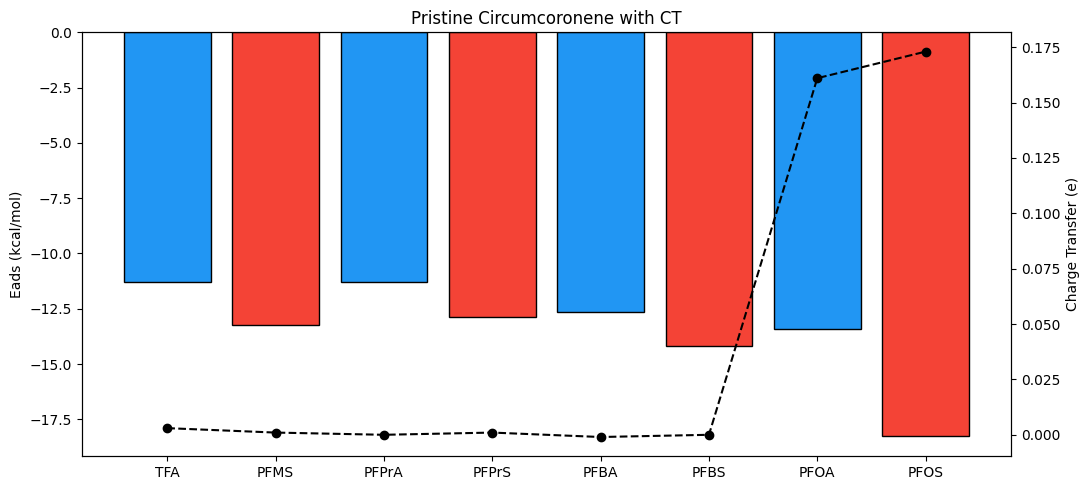

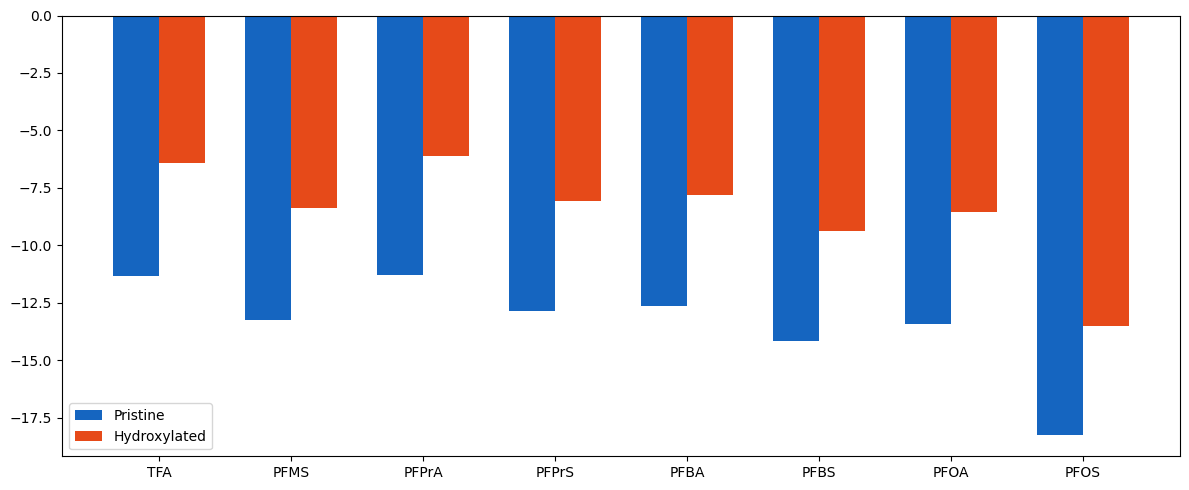

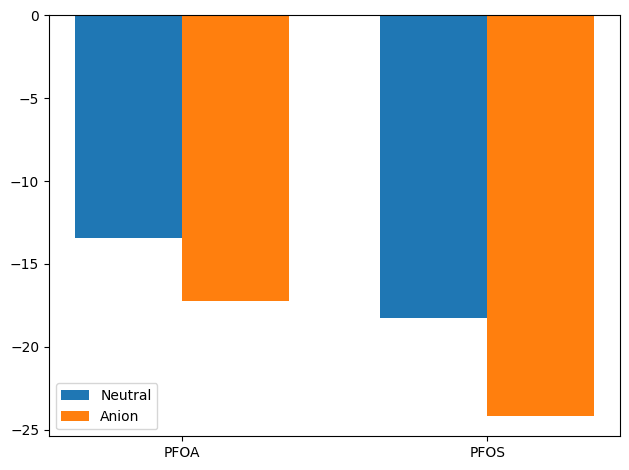

All figures generated


In [ ]:
names = pfas_list
eads_pristine = [ads_cc[n] for n in names]
eads_oh = [ads_ohcc[n] for n in names]
ct = [ct_cc[n] for n in names]
colors = ['#2196F3','#F44336']*4

# Figure 1: Pristine bar chart
plt.figure(figsize=(11,5))
bars = plt.bar(names, eads_pristine, color=colors, edgecolor='black')
plt.ylabel('Adsorption Energy (kcal mol⁻¹)')
plt.title('Pristine Circumcoronene')
plt.axhline(0, color='black')
for bar, val in zip(bars, eads_pristine):
    plt.text(bar.get_x()+bar.get_width()/2, val-0.5, f'{val}', ha='center', va='top')
plt.tight_layout()
plt.savefig('Fig1_pristine.png', dpi=300)
plt.show()

# Figure 2: Dual axis (pristine Eads + CT)
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(names, eads_pristine, color=colors, edgecolor='black')
ax1.set_ylabel('Eads (kcal/mol)')
ax2 = ax1.twinx()
ax2.plot(names, ct, 'ko--', linewidth=1.5, markersize=6)
ax2.set_ylabel('Charge Transfer (e)')
plt.title('Pristine Circumcoronene with CT')
plt.tight_layout()
plt.savefig('Fig2_dual.png', dpi=300)
plt.show()

# Figure 3: Pristine vs OH grouped
x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(x-width/2, eads_pristine, width, label='Pristine', color='#1565C0')
ax.bar(x+width/2, eads_oh, width, label='Hydroxylated', color='#E64A19')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
plt.tight_layout()
plt.savefig('Fig3_comparison.png', dpi=300)
plt.show()

# Figure 4: Neutral vs anion
neutral_vals = [ads_cc["PFOA"], ads_cc["PFOS"]]
anion_vals = [ads_anion["PFOA_anion"], ads_anion["PFOS_anion"]]
x = np.arange(2)
width = 0.35
fig, ax = plt.subplots()
ax.bar(x-width/2, neutral_vals, width, label='Neutral')
ax.bar(x+width/2, anion_vals, width, label='Anion')
ax.set_xticks(x)
ax.set_xticklabels(['PFOA', 'PFOS'])
ax.legend()
plt.tight_layout()
plt.savefig('Fig4_neutral_vs_anion.png', dpi=300)
plt.show()
print("All figures generated")

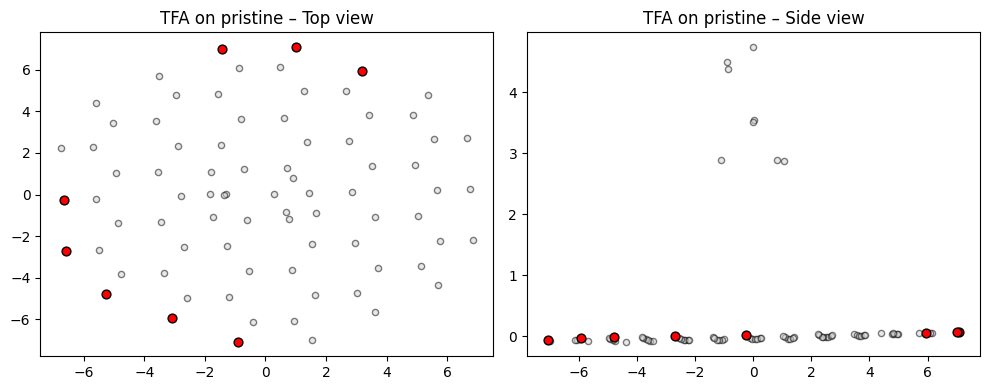

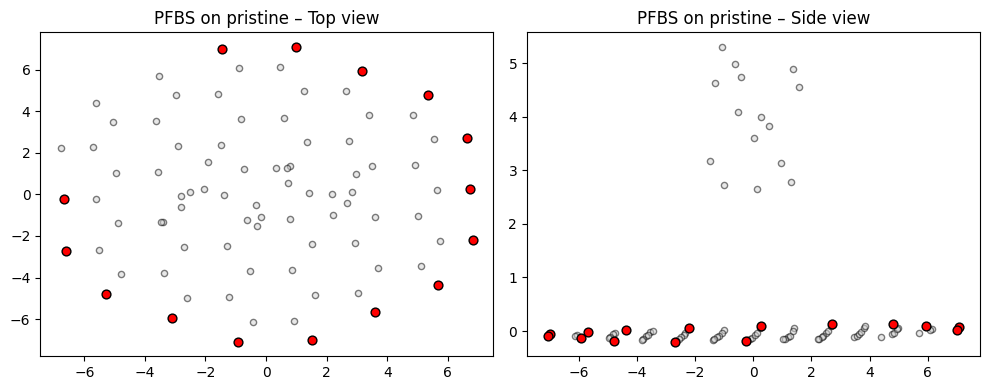

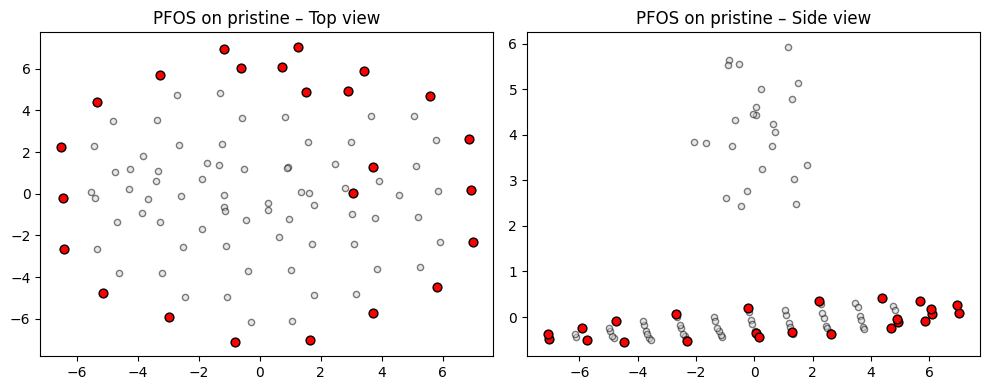

Projection plots saved


In [ ]:
surface_atoms = 72
def plot_projection(xyz_file, title):
    atoms = read(xyz_file)
    positions = atoms.get_positions()
    surface_pos = positions[:surface_atoms]
    pfas_pos = positions[surface_atoms:]
    fig, axes = plt.subplots(1,2, figsize=(10,4))
    axes[0].scatter(surface_pos[:,0], surface_pos[:,1], c='lightgray', s=20, edgecolors='k', alpha=0.5)
    axes[0].scatter(pfas_pos[:,0], pfas_pos[:,1], c='red', s=40, edgecolors='k')
    axes[0].set_title(f'{title} – Top view')
    axes[1].scatter(surface_pos[:,1], surface_pos[:,2], c='lightgray', s=20, edgecolors='k', alpha=0.5)
    axes[1].scatter(pfas_pos[:,1], pfas_pos[:,2], c='red', s=40, edgecolors='k')
    axes[1].set_title(f'{title} – Side view')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

for name in ["TFA", "PFBS", "PFOS"]:
    plot_projection(f"{name}_cc_or1_opt.xyz", f"{name} on pristine")
print("Projection plots saved")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/PFAS_analysis_results'
os.makedirs(save_dir, exist_ok=True)
for f in glob.glob('*_opt.xyz') + glob.glob('*.png') + glob.glob('*.txt') + glob.glob('*.json'):
    shutil.copy(f, save_dir)
results = {
    "ads_cc": ads_cc,
    "ads_ohcc": ads_ohcc,
    "ads_anion": ads_anion,
    "ct_cc": ct_cc,
    "ct_ohcc": ct_ohcc,
    "benchmark_gcp": benchmark_results,
    "energies": energies,
}
with open(f"{save_dir}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"All results saved to {save_dir}")

Mounted at /content/drive
All results saved to /content/drive/MyDrive/PFAS_analysis_results


In [ ]:
# Re-generate all figures as vector graphics (SVG + PDF)
import matplotlib.pyplot as plt
import numpy as np

# Data (use your final numbers)
names = ["TFA","PFMS","PFPrA","PFPrS","PFBA","PFBS","PFOA","PFOS"]
eads_pristine = [-11.31, -13.25, -11.30, -12.87, -12.63, -14.18, -13.41, -18.26]
eads_oh = [-6.40, -8.36, -6.11, -8.09, -7.79, -9.38, -8.54, -13.51]
ct = [0.003, 0.002, 0.000, 0.001, -0.001, -0.000, 0.161, 0.173]
colors = ['#2196F3','#F44336']*4

# Figure 1: Pristine bar chart
plt.figure(figsize=(11,5))
bars = plt.bar(names, eads_pristine, color=colors, edgecolor='black')
plt.ylabel('Adsorption Energy (kcal mol⁻¹)')
plt.title('Pristine Circumcoronene')
plt.axhline(0, color='black')
for bar, val in zip(bars, eads_pristine):
    plt.text(bar.get_x()+bar.get_width()/2, val-0.5, f'{val}', ha='center', va='top')
plt.tight_layout()
plt.savefig('Fig1_pristine.svg', format='svg')
plt.savefig('Fig1_pristine.pdf', format='pdf')
plt.close()

# Figure 2: Dual axis (pristine Eads + CT)
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(names, eads_pristine, color=colors, edgecolor='black')
ax1.set_ylabel('Eads (kcal/mol)')
ax2 = ax1.twinx()
ax2.plot(names, ct, 'ko--', linewidth=1.5, markersize=6)
ax2.set_ylabel('Charge Transfer (e)')
plt.title('Pristine Circumcoronene with CT')
plt.tight_layout()
plt.savefig('Fig2_dual.svg', format='svg')
plt.savefig('Fig2_dual.pdf', format='pdf')
plt.close()

# Figure 3: Pristine vs OH grouped
x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(x-width/2, eads_pristine, width, label='Pristine', color='#1565C0')
ax.bar(x+width/2, eads_oh, width, label='Hydroxylated', color='#E64A19')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
plt.tight_layout()
plt.savefig('Fig3_comparison.svg', format='svg')
plt.savefig('Fig3_comparison.pdf', format='pdf')
plt.close()

# Figure 4: Neutral vs anion (PFOA, PFOS)
neutral_vals = [-13.41, -18.26]
anion_vals = [-17.24, -24.19]
x = np.arange(2)
width = 0.35
fig, ax = plt.subplots()
ax.bar(x-width/2, neutral_vals, width, label='Neutral')
ax.bar(x+width/2, anion_vals, width, label='Anion')
ax.set_xticks(x)
ax.set_xticklabels(['PFOA', 'PFOS'])
ax.legend()
plt.tight_layout()
plt.savefig('Fig4_neutral_vs_anion.svg', format='svg')
plt.savefig('Fig4_neutral_vs_anion.pdf', format='pdf')
plt.close()

print("All figures saved as SVG and PDF.")

All figures saved as SVG and PDF.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datetime import datetime
import os

# Create a folder with current date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = f"/content/drive/MyDrive/PFAS_xtb_run_{timestamp}"
os.makedirs(save_folder, exist_ok=True)
print(f"Files will be saved to: {save_folder}")

Files will be saved to: /content/drive/MyDrive/PFAS_xtb_run_20260605_113038


In [ ]:
import shutil
import glob
import json

# 1. Copy all .xyz files (optimized structures and complexes)
for f in glob.glob("*.xyz"):
    shutil.copy(f, save_folder)

# 2. Copy all .opt.xyz files (optimized geometries)
for f in glob.glob("*_opt.xyz"):
    shutil.copy(f, save_folder)

# 3. Copy all figure files (PNG, SVG, PDF)
for ext in ["png", "svg", "pdf"]:
    for f in glob.glob(f"*.{ext}"):
        shutil.copy(f, save_folder)

# 4. Save the final results dictionary as JSON
# Make sure 'results' dictionary exists (if not, create it)
if 'results' not in dir():
    results = {
        "ads_cc": ads_cc,
        "ads_ohcc": ads_ohcc,
        "ads_anion": ads_anion,
        "ct_cc": ct_cc,
        "ct_ohcc": ct_ohcc,
        "energies": energies,
        "benchmark_results": benchmark_results if 'benchmark_results' in dir() else {}
    }
with open(f"{save_folder}/results.json", "w") as f:
    json.dump(results, f, indent=2)

# 5. Save the current Colab notebook (.ipynb) – requires the notebook to have a name
# If your notebook is untitled, you can download it manually (see cell below)
try:
    from google.colab import files
    # Download the current notebook (will prompt download to local machine, not to Drive directly)
    # To save directly to Drive, we need to copy the .ipynb from /content/ if it exists
    if os.path.exists("/content/PFAS_final.ipynb"):
        shutil.copy("/content/PFAS_final.ipynb", save_folder)
    else:
        # If no notebook file is found, we can create one from the current Python environment?
        print("No notebook file found in /content. To save the notebook, please rename it first (File > Rename) and then rerun this cell.")
except:
    print("Could not save notebook automatically. Please manually download via File > Download .ipynb")

print(f"All files saved to {save_folder}")

No notebook file found in /content. To save the notebook, please rename it first (File > Rename) and then rerun this cell.
All files saved to /content/drive/MyDrive/PFAS_xtb_run_20260605_113038
